# Visualisation
**COSC 301 Project — Malaysia State-Level Socioeconomic & Health Outcomes**

This notebook produces figures for the final report. Each section is one self-contained figure, saved to `figures/`.

| Figure | Description |
|---|---|
| Fig 1 | State income rankings (2022) — W.P. Kuala Lumpur flagged * |
| Fig 2 | State poverty rates (2022) — W.P. Kuala Lumpur flagged * |
| Fig 3 | Hospital beds per 1 000 by state — W.P. Kuala Lumpur flagged * |
| Fig 4 | Income vs beds per capita (scatter) — KUL shown as distinct marker |
| Fig 5 | Poverty vs facilities per capita (scatter) — KUL shown as distinct marker |
| Fig 6 | Income trends 2019–2024 (selected states) |
| Fig 7 | Correlation heatmap |
| Fig 8 | Long-term income trends 1970–2024 |

**Data sources:** `combined_state.csv` (income, poverty, Gini; 1970–2024) and `health_state.csv` (beds, facilities per capita).

**Note on scope:** W.P. Putrajaya is excluded from all charts (administrative enclave). W.P. Kuala Lumpur is included but visually distinguished as an urban capital territory (`*`).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
import numpy as np

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parent

CLEAN_DIR = PROJECT_ROOT / "data" / "clean"
FIG_DIR = PROJECT_ROOT / "figures"
FIG_DIR.mkdir(exist_ok=True)

combined = pd.read_csv(CLEAN_DIR / "combined_state.csv")
hs = pd.read_csv(CLEAN_DIR / "health_state.csv")

# Merged view for cross-sectional figures (recent years with health data)
df = combined[combined["year"].isin([2019, 2022, 2024])].merge(
    hs, on=["state_code", "state", "year"], suffixes=("", "_hs")
)
df = df.drop(columns=[c for c in df.columns if c.endswith("_hs")])

# East Malaysia flag
EAST = {"Sabah", "Sarawak", "W.P. Labuan"}
df["region"] = df["state"].apply(lambda s: "East" if s in EAST else "West")

# Main dataframe: exclude W.P. Putrajaya (admin enclave, not a general-purpose state)
df_main = df[df["territory_type"] != "admin"].copy()

# For Fig 6 trend lines: recent years only, excl. W.P. Putrajaya
se_main = combined[
    combined["year"].isin([2019, 2022, 2024]) &
    (combined["territory_type"] != "admin")
].copy()

ref = df_main[df_main.year == 2022].copy()

# Colour palette: East Malaysia = warm orange; West = blue; KUL = distinct green
PALETTE = {s: "#e07b39" if s in EAST else "#4c72b0" for s in df.state.unique()}
PALETTE["W.P. Kuala Lumpur"] = "#2ca02c"   # visually distinguish urban capital

# Global style
sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["figure.dpi"] = 120

print("Output directory:", FIG_DIR)
print("ref shape (excl. PJY):", ref.shape)

Output directory: c:\Users\aliff\Documents\GitHub\inequality-analysis\figures
ref shape (excl. PJY): (15, 17)


---
### Figure 1 — Mean Household Income by State (2022)

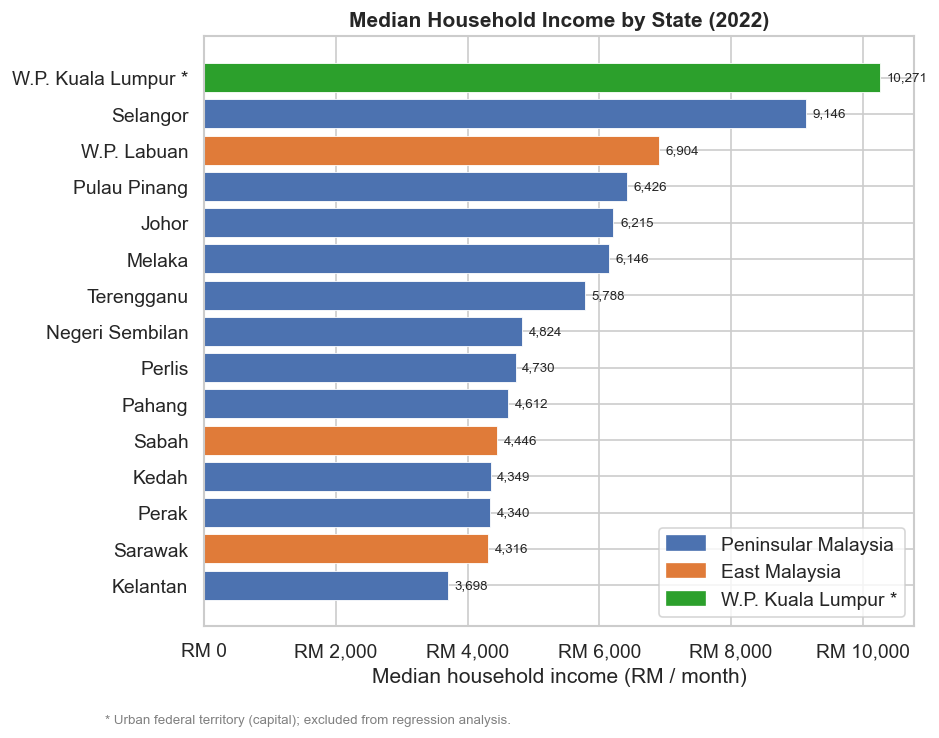

Saved fig1_income_ranking.png


In [10]:
data = ref.sort_values("income_median", ascending=True)
# Append * to KUL label so readers know it is the urban capital territory
data = data.copy()
data["label"] = data["state"].apply(
    lambda s: f"{s} *" if s == "W.P. Kuala Lumpur" else s
)
colors = [PALETTE[s] for s in data.state]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(data.label, data.income_median, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Median household income (RM / month)")
ax.set_title("Median Household Income by State (2022)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"RM {x:,.0f}"))

# Value labels (median income, matching bar lengths)
for bar, val in zip(bars, data.income_median):
    ax.text(val + 100, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=8)

# Legend
legend_handles = [
    Patch(color="#4c72b0", label="Peninsular Malaysia"),
    Patch(color="#e07b39", label="East Malaysia"),
    Patch(color="#2ca02c", label="W.P. Kuala Lumpur *"),
]
ax.legend(handles=legend_handles, loc="lower right")
fig.text(0.12, -0.02,
         "* Urban federal territory (capital); excluded from regression analysis.",
         fontsize=8, color="grey")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig1_income_ranking.png", bbox_inches="tight")
plt.show()
print("Saved fig1_income_ranking.png")

---
### Figure 2 — Poverty Rate by State (2022)

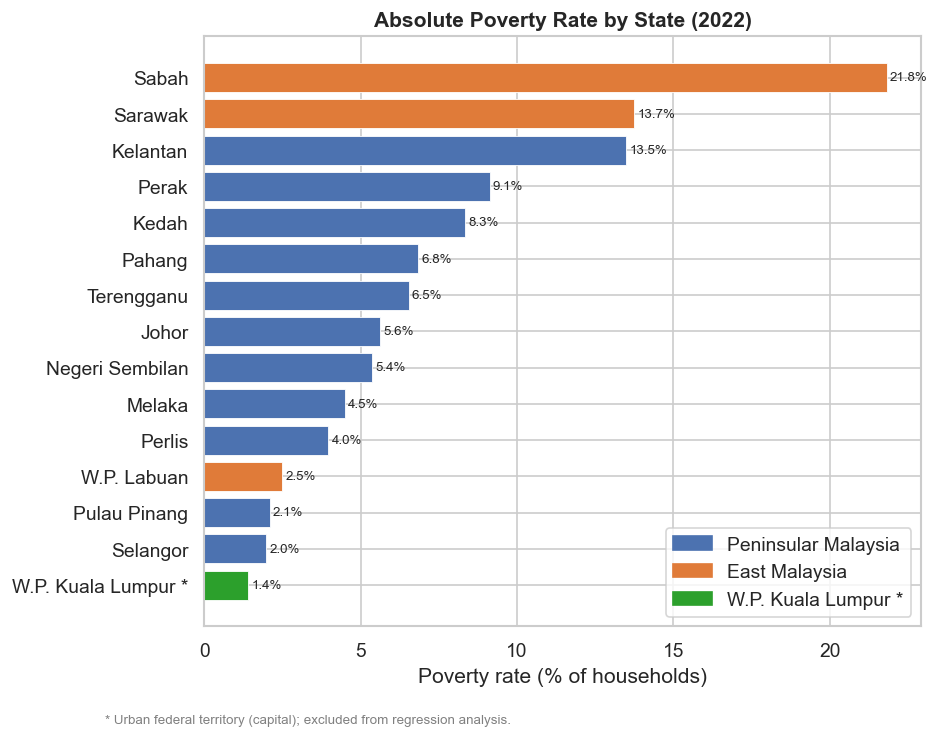

Saved fig2_poverty_ranking.png


In [3]:
data = ref.sort_values("poverty_absolute", ascending=False).copy()
data["label"] = data["state"].apply(
    lambda s: f"{s} *" if s == "W.P. Kuala Lumpur" else s
)
colors = [PALETTE[s] for s in data.state]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(data.label, data.poverty_absolute, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Poverty rate (% of households)")
ax.set_title("Absolute Poverty Rate by State (2022)", fontweight="bold")

for bar, val in zip(bars, data.poverty_absolute):
    ax.text(val + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8)

legend_handles = [
    Patch(color="#4c72b0", label="Peninsular Malaysia"),
    Patch(color="#e07b39", label="East Malaysia"),
    Patch(color="#2ca02c", label="W.P. Kuala Lumpur *"),
]
ax.legend(handles=legend_handles, loc="lower right")
ax.invert_yaxis()
fig.text(0.12, -0.02,
         "* Urban federal territory (capital); excluded from regression analysis.",
         fontsize=8, color="grey")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig2_poverty_ranking.png", bbox_inches="tight")
plt.show()
print("Saved fig2_poverty_ranking.png")

---
### Figure 3 — Hospital Beds per 1 000 Population by State

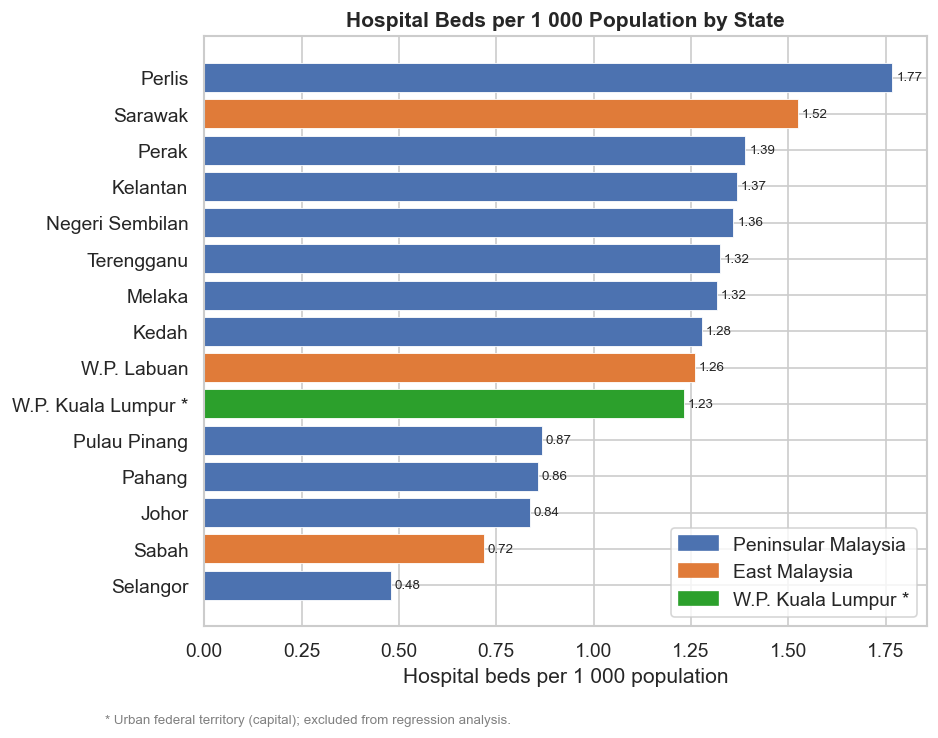

Saved fig3_beds_ranking.png


In [4]:
data = ref.sort_values("beds_per_1000", ascending=True).copy()
data["label"] = data["state"].apply(
    lambda s: f"{s} *" if s == "W.P. Kuala Lumpur" else s
)
colors = [PALETTE[s] for s in data.state]

fig, ax = plt.subplots(figsize=(8, 6))
bars = ax.barh(data.label, data.beds_per_1000, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xlabel("Hospital beds per 1 000 population")
ax.set_title("Hospital Beds per 1 000 Population by State", fontweight="bold")

for bar, val in zip(bars, data.beds_per_1000):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:.2f}", va="center", fontsize=8)

legend_handles = [
    Patch(color="#4c72b0", label="Peninsular Malaysia"),
    Patch(color="#e07b39", label="East Malaysia"),
    Patch(color="#2ca02c", label="W.P. Kuala Lumpur *"),
]
ax.legend(handles=legend_handles, loc="lower right")
fig.text(0.12, -0.02,
         "* Urban federal territory (capital); excluded from regression analysis.",
         fontsize=8, color="grey")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig3_beds_ranking.png", bbox_inches="tight")
plt.show()
print("Saved fig3_beds_ranking.png")

---
### Figure 4 — Income vs Hospital Beds per Capita (Scatter)

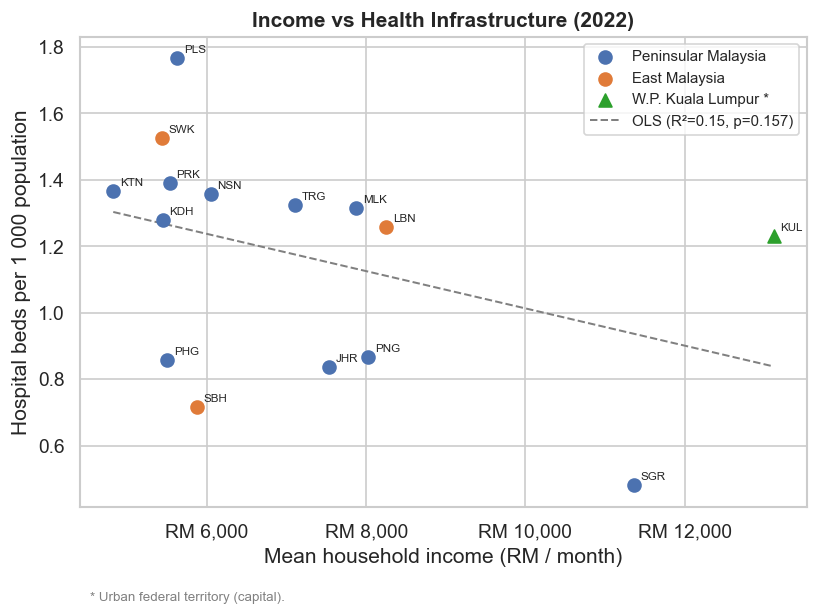

Saved fig4_income_vs_beds.png


In [5]:
from scipy import stats

fig, ax = plt.subplots(figsize=(7, 5))

# Plot by group: East, West (non-KUL), and KUL separately
for label, mask_fn, color, marker in [
    ("Peninsular Malaysia", lambda r: (~r["state"].isin(EAST)) & (r["state"] != "W.P. Kuala Lumpur"), "#4c72b0", "o"),
    ("East Malaysia",       lambda r: r["state"].isin(EAST),                                          "#e07b39", "o"),
    ("W.P. Kuala Lumpur *", lambda r: r["state"] == "W.P. Kuala Lumpur",                              "#2ca02c", "^"),
]:
    group = ref[mask_fn(ref)]
    ax.scatter(group.income_mean, group.beds_per_1000, color=color, s=60,
               label=label, marker=marker, zorder=3)

# State code annotations
for _, row in ref.iterrows():
    ax.annotate(row.state_code, (row.income_mean, row.beds_per_1000),
                fontsize=7, ha="left", va="bottom", xytext=(4, 2),
                textcoords="offset points")

# Regression line (using full ref — including KUL for transparency)
mask = ref.income_mean.notna() & ref.beds_per_1000.notna()
slope, intercept, r, p, _ = stats.linregress(ref.loc[mask, "income_mean"],
                                              ref.loc[mask, "beds_per_1000"])
x_line = pd.Series([ref.income_mean.min(), ref.income_mean.max()])
ax.plot(x_line, slope * x_line + intercept, color="grey", linestyle="--",
        linewidth=1.2, label=f"OLS (R²={r**2:.2f}, p={p:.3f})")

ax.set_xlabel("Mean household income (RM / month)")
ax.set_ylabel("Hospital beds per 1 000 population")
ax.set_title("Income vs Health Infrastructure (2022)", fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"RM {x:,.0f}"))
ax.legend(fontsize=9)
fig.text(0.12, -0.02,
         "* Urban federal territory (capital).",
         fontsize=8, color="grey")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig4_income_vs_beds.png", bbox_inches="tight")
plt.show()
print("Saved fig4_income_vs_beds.png")

---
### Figure 5 — Poverty Rate vs Facilities per 100k (Scatter)

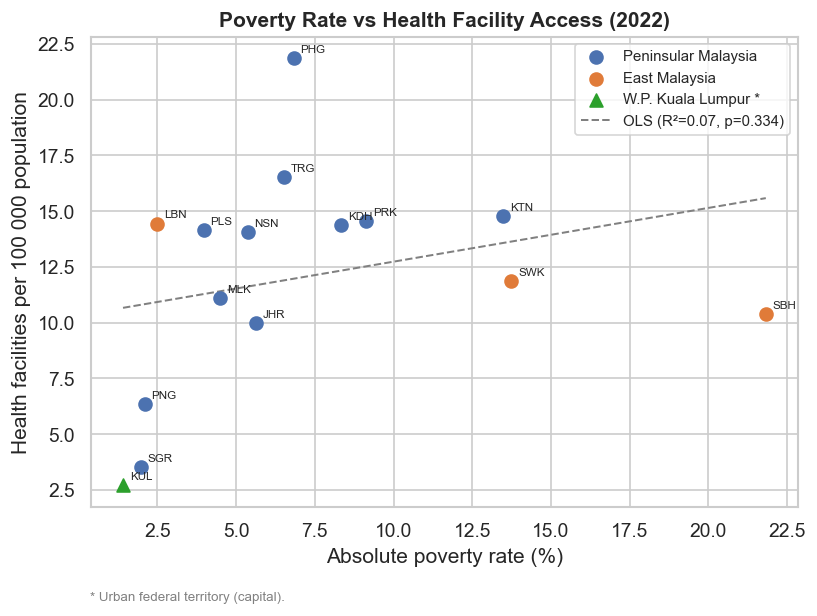

Saved fig5_poverty_vs_facilities.png


In [6]:
fig, ax = plt.subplots(figsize=(7, 5))

for label, mask_fn, color, marker in [
    ("Peninsular Malaysia", lambda r: (~r["state"].isin(EAST)) & (r["state"] != "W.P. Kuala Lumpur"), "#4c72b0", "o"),
    ("East Malaysia",       lambda r: r["state"].isin(EAST),                                          "#e07b39", "o"),
    ("W.P. Kuala Lumpur *", lambda r: r["state"] == "W.P. Kuala Lumpur",                              "#2ca02c", "^"),
]:
    group = ref[mask_fn(ref)]
    ax.scatter(group.poverty_absolute, group.facilities_per_100k, color=color,
               s=60, label=label, marker=marker, zorder=3)

for _, row in ref.iterrows():
    ax.annotate(row.state_code, (row.poverty_absolute, row.facilities_per_100k),
                fontsize=7, ha="left", va="bottom", xytext=(4, 2),
                textcoords="offset points")

mask = ref.poverty_absolute.notna() & ref.facilities_per_100k.notna()
slope, intercept, r, p, _ = stats.linregress(ref.loc[mask, "poverty_absolute"],
                                              ref.loc[mask, "facilities_per_100k"])
x_line = pd.Series([ref.poverty_absolute.min(), ref.poverty_absolute.max()])
ax.plot(x_line, slope * x_line + intercept, color="grey", linestyle="--",
        linewidth=1.2, label=f"OLS (R²={r**2:.2f}, p={p:.3f})")

ax.set_xlabel("Absolute poverty rate (%)")
ax.set_ylabel("Health facilities per 100 000 population")
ax.set_title("Poverty Rate vs Health Facility Access (2022)", fontweight="bold")
ax.legend(fontsize=9)
fig.text(0.12, -0.02,
         "* Urban federal territory (capital).",
         fontsize=8, color="grey")

plt.tight_layout()
plt.savefig(FIG_DIR / "fig5_poverty_vs_facilities.png", bbox_inches="tight")
plt.show()
print("Saved fig5_poverty_vs_facilities.png")

---
### Figure 6 — Income Trends 2019–2024 (Selected States)

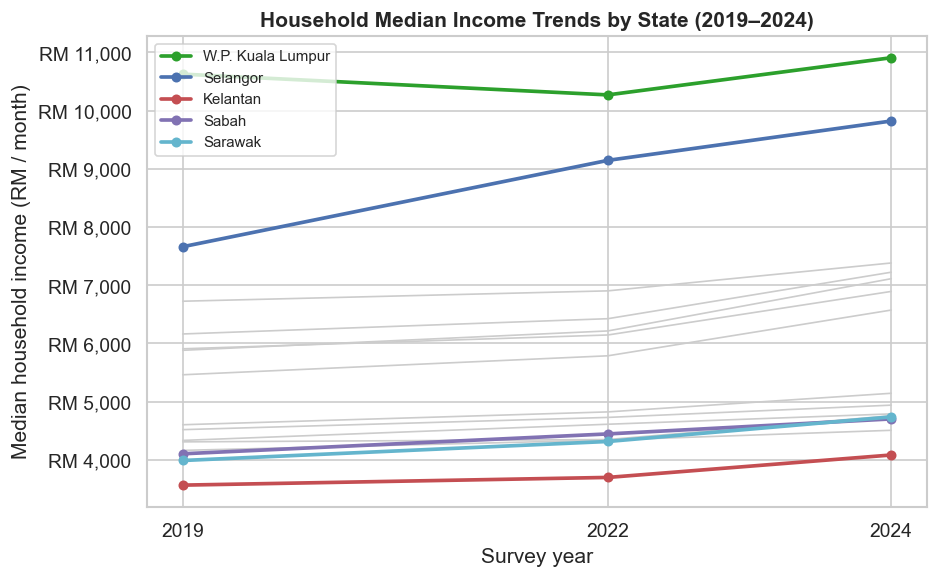

Saved fig6_income_trends.png


In [7]:
# Highlight the richest, poorest, and most improved states (excl. W.P. Putrajaya)
HIGHLIGHT = ["W.P. Kuala Lumpur", "Selangor", "Kelantan", "Sabah", "Sarawak"]

fig, ax = plt.subplots(figsize=(8, 5))

# Background: all other states in light grey (uses se_main, PJY excluded)
for state, grp in se_main.groupby("state"):
    if state not in HIGHLIGHT:
        ax.plot(grp.year, grp.income_median, color="#cccccc", linewidth=1, zorder=1)

# Highlighted states
colors_hl = ["#2ca02c", "#4c72b0", "#c44e52", "#8172b3", "#64b5cd"]
for state, color in zip(HIGHLIGHT, colors_hl):
    grp = se_main[se_main.state == state].sort_values("year")
    ax.plot(grp.year, grp.income_median, color=color, linewidth=2.2,
            marker="o", markersize=5, label=state, zorder=3)

ax.set_xticks([2019, 2022, 2024])
ax.set_xlabel("Survey year")
ax.set_ylabel("Median household income (RM / month)")
ax.set_title("Household Median Income Trends by State (2019–2024)", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"RM {x:,.0f}"))
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig6_income_trends.png")
plt.show()
print("Saved fig6_income_trends.png")

---
### Figure 7 — Correlation Heatmap

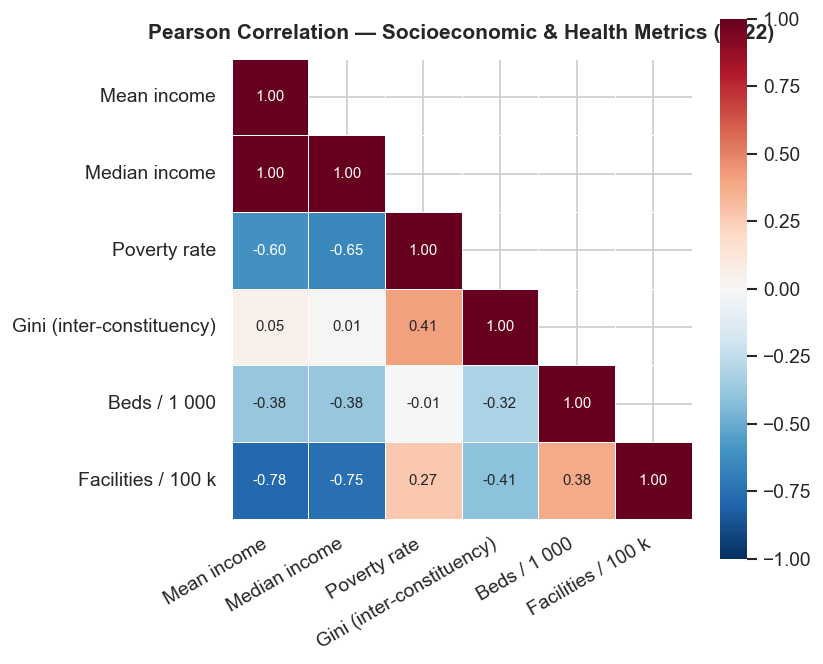

Saved fig7_correlation_heatmap.png


In [8]:
corr_cols = {
    "income_mean": "Mean income",
    "income_median": "Median income",
    "poverty_absolute": "Poverty rate",
    "gini": "Gini (inter-constituency)",
    "beds_per_1000": "Beds / 1 000",
    "facilities_per_100k": "Facilities / 100 k",
}

corr_data = ref[list(corr_cols.keys())].rename(columns=corr_cols)
corr_matrix = corr_data.corr(method="pearson")

fig, ax = plt.subplots(figsize=(7, 6))
mask = pd.DataFrame(False, index=corr_matrix.index, columns=corr_matrix.columns)

mask_arr = np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1)
mask = pd.DataFrame(mask_arr, index=corr_matrix.index, columns=corr_matrix.columns)

sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5, ax=ax,
    annot_kws={"size": 9},
)
ax.set_title("Pearson Correlation — Socioeconomic & Health Metrics (2022)",
             fontweight="bold", pad=12)
plt.xticks(rotation=30, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig7_correlation_heatmap.png")
plt.show()
print("Saved fig7_correlation_heatmap.png")

---
### Figure 8 — Long-term Income Trends by State (1970–2024)

Uses `combined_state`, which spans DOSM HIES state-level aggregates (1970–2016, 2020) and constituency-derived figures (2019, 2022, 2024). The vertical dashed lines mark the COVID-19 survey gap (no surveys 2020–2021).

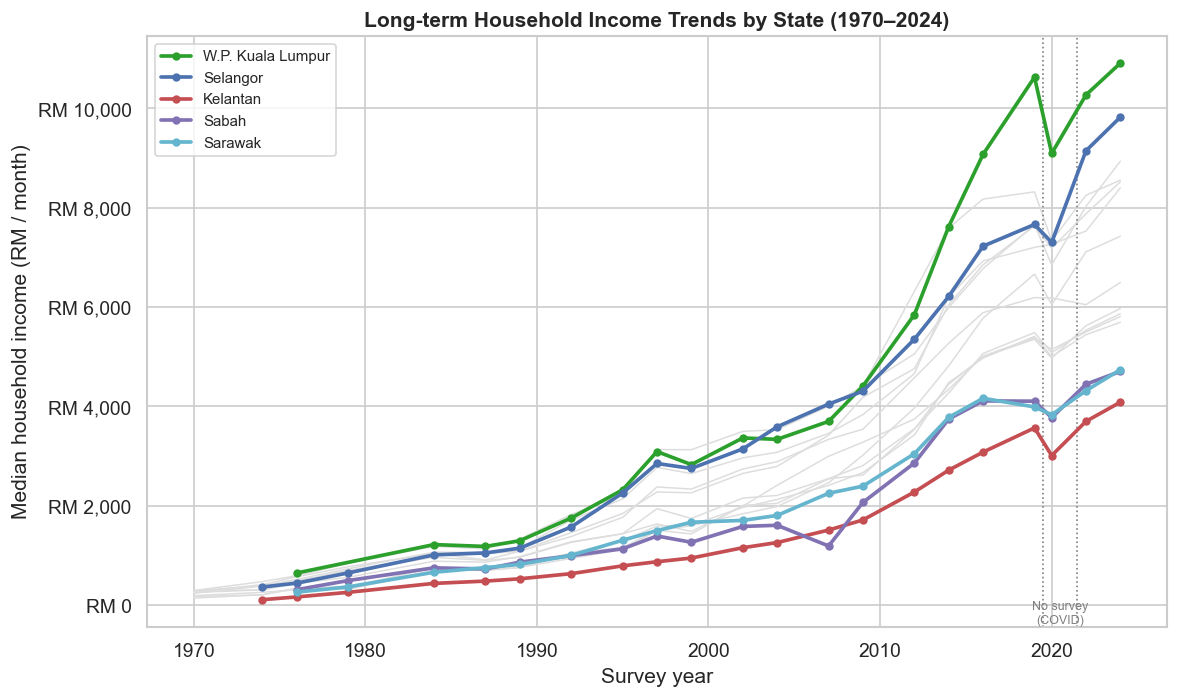

Saved fig8_historical_income.png


In [9]:
HIGHLIGHT_HIST = ["W.P. Kuala Lumpur", "Selangor", "Kelantan", "Sabah", "Sarawak"]
hist_main = combined[combined["territory_type"] != "admin"].copy()

fig, ax = plt.subplots(figsize=(10, 6))

# Background: all other states in light grey
for state, grp in hist_main.groupby("state"):
    if state not in HIGHLIGHT_HIST:
        ax.plot(grp.sort_values("year")["year"],
                grp.sort_values("year")["income_mean"],
                color="#dddddd", linewidth=0.9, zorder=1)

# Highlighted states
colors_hl = ["#2ca02c", "#4c72b0", "#c44e52", "#8172b3", "#64b5cd"]
for state, color in zip(HIGHLIGHT_HIST, colors_hl):
    grp = hist_main[hist_main.state == state].sort_values("year")
    ax.plot(grp["year"], grp["income_median"], color=color, linewidth=2.2,
            marker="o", markersize=4, label=state, zorder=3)

# Mark the COVID gap (no survey 2019–2022, data jumps from 2019 → 2022)
ax.axvline(x=2019.5, color="grey", linestyle=":", linewidth=1.0)
ax.axvline(x=2021.5, color="grey", linestyle=":", linewidth=1.0)
ax.text(2020.5, ax.get_ylim()[0], "No survey\n(COVID)", ha="center",
        fontsize=7.5, color="grey", va="bottom")

ax.set_xlabel("Survey year")
ax.set_ylabel("Median household income (RM / month)")
ax.set_title("Long-term Household Income Trends by State (1970–2024)", fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"RM {x:,.0f}"))
ax.legend(loc="upper left", fontsize=9)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig8_historical_income.png")
plt.show()
print("Saved fig8_historical_income.png")